In [1]:
# ------------------------------------------------------------------ #
#  Notebook 06 · Geographic Analysis                                 #
#  Input : data/processed/retail_clean.parquet                       #
#  Output: data/processed/geo_summary.parquet                        #
# ------------------------------------------------------------------ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

CLEAN_PATH = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\retail_clean.parquet'
SAVE_PATH  = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\geo_summary.parquet'

In [2]:
df = pd.read_parquet(CLEAN_PATH)

# Aggregate key business metrics at country level.
# AOV (Average Order Value) = total revenue divided by number of distinct invoices.

geo = (
    df.groupby('Country')
    .agg(
        Revenue     = ('Revenue',     'sum'),
        Orders      = ('Invoice',     'nunique'),
        Customers   = ('Customer ID', 'nunique'),
        Avg_Qty     = ('Quantity',    'mean')
    )
    .reset_index()
)

geo['AOV']            = (geo['Revenue'] / geo['Orders']).round(2)
geo['Revenue_Share']  = (geo['Revenue'] / geo['Revenue'].sum() * 100).round(2)
geo['Revenue']        = geo['Revenue'].round(2)
geo = geo.sort_values('Revenue', ascending=False).reset_index(drop=True)

print(f'Countries : {len(geo)}')
print(f'\nTop 10 by Revenue:')
geo.head(10)

Countries : 41

Top 10 by Revenue:


,Country,Revenue,Orders,Customers,Avg_Qty,AOV,Revenue_Share
0,United Kingdom,14294084.55,33384,5336,12.180816,428.17,83.66
1,EIRE,596997.43,542,5,20.463063,1101.47,3.49
2,Netherlands,549773.41,216,22,77.017667,2545.25,3.22
3,Germany,383419.24,756,107,14.128626,507.17,2.24
4,France,309855.89,594,95,20.631664,521.64,1.81
5,Australia,167800.01,89,15,58.190129,1885.39,0.98
6,Spain,97994.50,147,41,14.032837,666.63,0.57
7,Switzerland,93400.94,82,22,17.647238,1139.04,0.55
8,Sweden,86045.14,98,19,69.771902,878.01,0.50
9,Denmark,67422.69,42,12,314.029101,1605.30,0.39


## 1. Visualisations

We look at revenue distribution across countries, order behaviour,
and a choropleth map to see the geographic spread of the business.

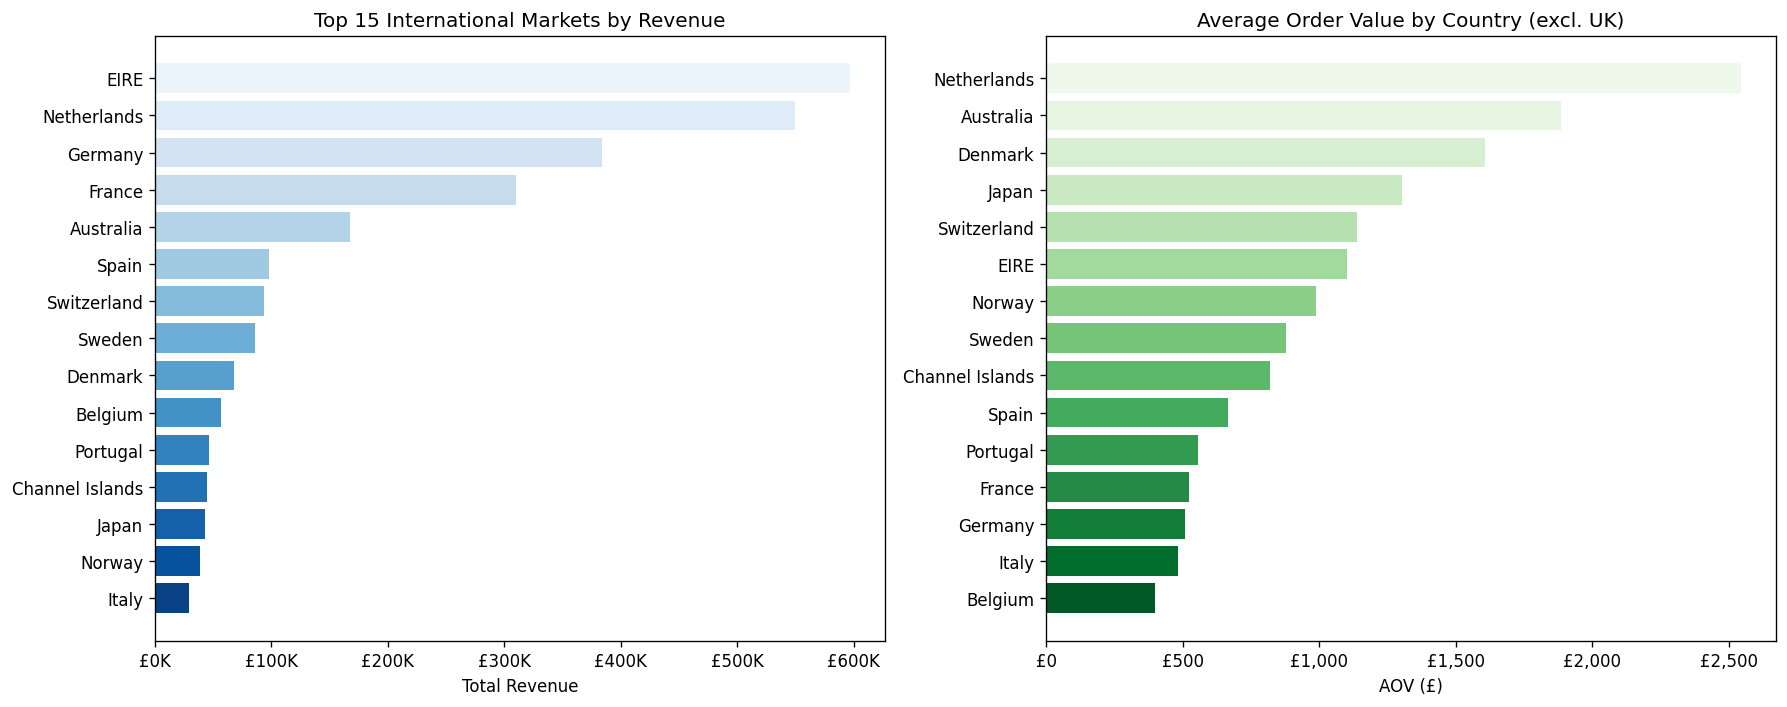

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Revenue share excluding UK to see international distribution clearly
intl = geo[geo['Country'] != 'United Kingdom'].head(15).sort_values('Revenue')

axes[0].barh(
    intl['Country'],
    intl['Revenue'],
    color=sns.color_palette('Blues_r', len(intl))
)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].set_title('Top 15 International Markets by Revenue')
axes[0].set_xlabel('Total Revenue')

# AOV by country — reveals wholesale vs retail buying behaviour
intl_aov = geo[geo['Country'] != 'United Kingdom'].head(15).sort_values('AOV')

axes[1].barh(
    intl_aov['Country'],
    intl_aov['AOV'],
    color=sns.color_palette('Greens_r', len(intl_aov))
)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].set_title('Average Order Value by Country (excl. UK)')
axes[1].set_xlabel('AOV (£)')

plt.tight_layout()
plt.show()

## 2. Choropleth Map

An interactive world map showing revenue by country gives an immediate
visual sense of the business's geographic concentration and reach.

In [4]:
# Plotly choropleth uses ISO country names — 'EIRE' needs to be renamed
# to 'Ireland' for the map to match it to the correct geography.

geo_map = geo.copy()
geo_map['Country'] = geo_map['Country'].replace({'EIRE': 'Ireland'})

fig = px.choropleth(
    geo_map,
    locations='Country',
    locationmode='country names',
    color='Revenue',
    hover_name='Country',
    hover_data={
        'Revenue'       : ':,.0f',
        'Orders'        : ':,',
        'Customers'     : ':,',
        'AOV'           : ':,.0f',
        'Revenue_Share' : ':.2f'
    },
    color_continuous_scale='Blues',
    title='Global Revenue Distribution'
)

fig.update_layout(
    title_font_size=14,
    coloraxis_colorbar_title='Revenue (£)'
)

fig.show()

# Save geo summary
geo.to_parquet(SAVE_PATH, index=False)
print(f'Saved : {SAVE_PATH}')
print(f'Shape : {geo.shape}')

Saved : E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\geo_summary.parquet
Shape : (41, 7)
